<a href="https://colab.research.google.com/github/bavinkdevadas-hub/ML-Projects/blob/main/Customer%20Churn%20Prediction/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Problem statement

With customer churn as the prediction variable, the task involves using customer demographics, service usage, account information, and behavioral features to predict whether a customer is likely to leave a company. This can be approached as a binary classification problem, where the model predicts whether a customer will churn or remain with the company.

Customer retention is crucial for business growth, as losing existing customers can lead to significant revenue loss and increased acquisition costs. Early identification of customers who are likely to churn can help businesses take proactive actions, improve customer satisfaction, and develop targeted retention strategies.

The objective of this project is to develop a machine learning model that analyzes customer information and predicts the likelihood of churn. The model can help businesses identify high-risk customers, understand factors contributing to churn, and support data-driven customer retention and decision making strategies.


In [ ]:
import numpy as num
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df.drop(["customerID"],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
df.duplicated().sum()


np.int64(22)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

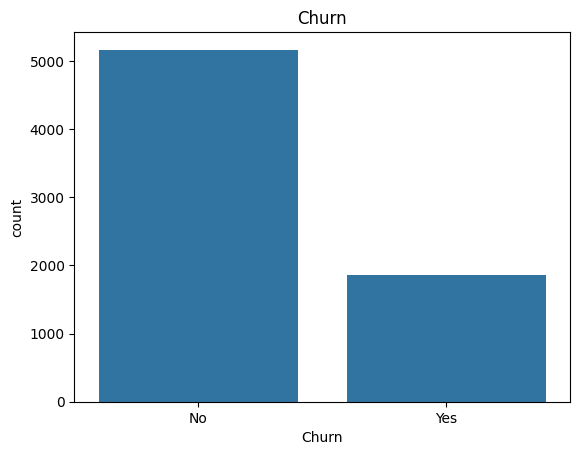

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title('Churn')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

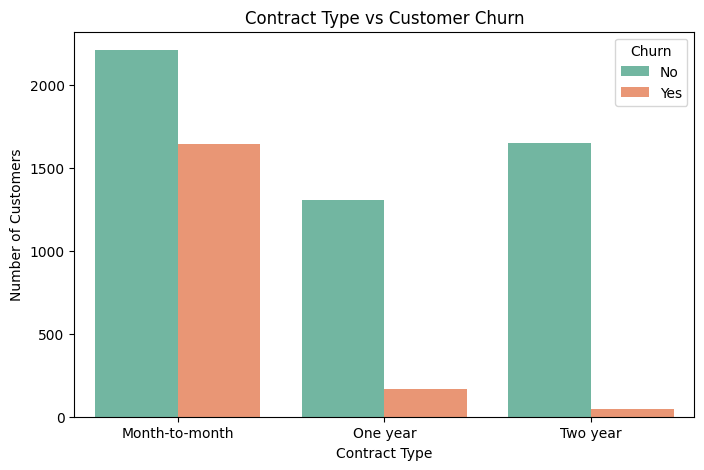

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

/tmp/ipykernel_4863/2686393696.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette='Set2')


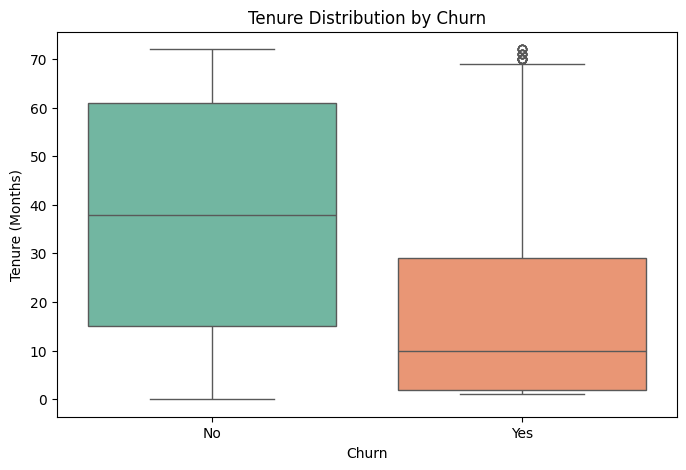

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='tenure', palette='Set2')

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

/tmp/ipykernel_4863/1858495415.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')


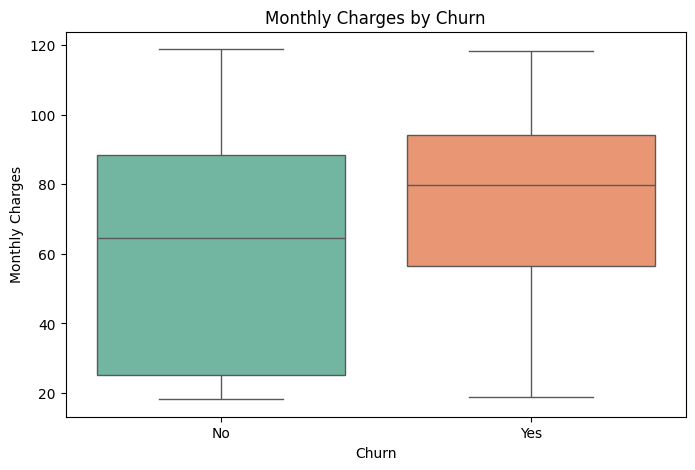

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

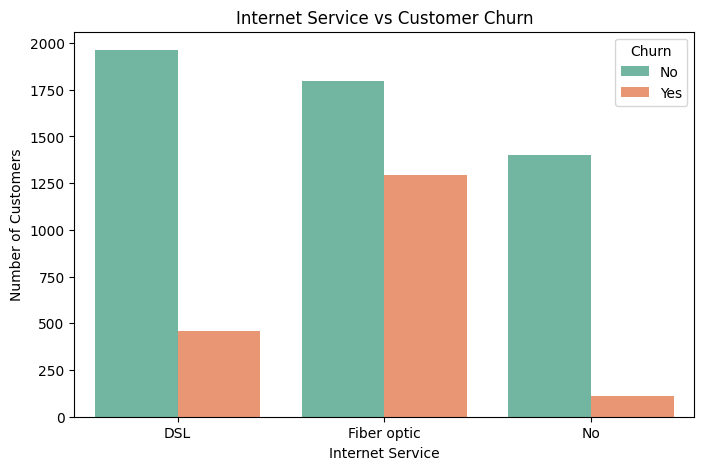

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set2')

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

In [ ]:
# Converting all the categorical data to numerical values using LabelEncoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['Partner'] = le.fit_transform(df['Partner'])
df['Dependents'] = le.fit_transform(df['Dependents'])
df['PhoneService'] = le.fit_transform(df['PhoneService'])
df['MultipleLines'] = le.fit_transform(df['MultipleLines'])
df['InternetService'] = le.fit_transform(df['InternetService'])
df['OnlineSecurity'] = le.fit_transform(df['OnlineSecurity'])
df['OnlineBackup'] = le.fit_transform(df['OnlineBackup'])
df['DeviceProtection'] = le.fit_transform(df['DeviceProtection'])
df['TechSupport'] = le.fit_transform(df['TechSupport'])
df['StreamingTV'] = le.fit_transform(df['StreamingTV'])
df['StreamingMovies'] = le.fit_transform(df['StreamingMovies'])
df['Contract'] = le.fit_transform(df['Contract'])
df['PaperlessBilling'] = le.fit_transform(df['PaperlessBilling'])
df['PaymentMethod'] = le.fit_transform(df['PaymentMethod'])
df['Churn'] = le.fit_transform(df['Churn'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   int64  
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   int64  
 3   Dependents        7021 non-null   int64  
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   int64  
 6   MultipleLines     7021 non-null   int64  
 7   InternetService   7021 non-null   int64  
 8   OnlineSecurity    7021 non-null   int64  
 9   OnlineBackup      7021 non-null   int64  
 10  DeviceProtection  7021 non-null   int64  
 11  TechSupport       7021 non-null   int64  
 12  StreamingTV       7021 non-null   int64  
 13  StreamingMovies   7021 non-null   int64  
 14  Contract          7021 non-null   int64  
 15  PaperlessBilling  7021 non-null   int64  
 16  PaymentMethod     7021 non-null   int64  
 17  

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Separate features and target
x = df.drop(columns=['Churn'])
y = df['Churn']

# Apply SMOTE
smote = SMOTE(random_state=42)
x_res, y_res = smote.fit_resample(x, y)

# Combine into one DataFrame
df_smote = pd.DataFrame(x_res, columns=x.columns)
df_smote['Churn'] = y_res
print(df_smote['Churn'].value_counts())

Churn
0    5153
1    5153
Name: count, dtype: int64


In [ ]:
df=df_smote

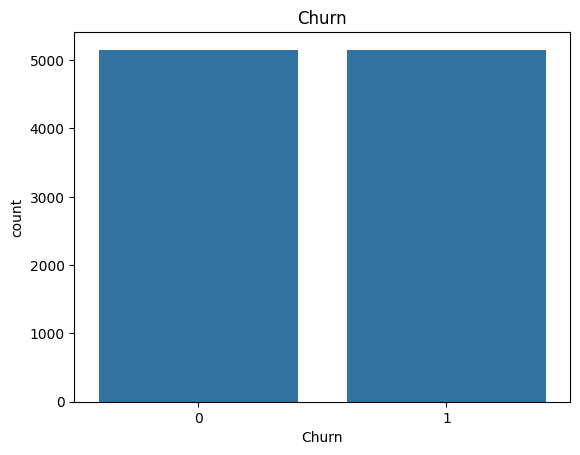

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title('Churn')
plt.show()

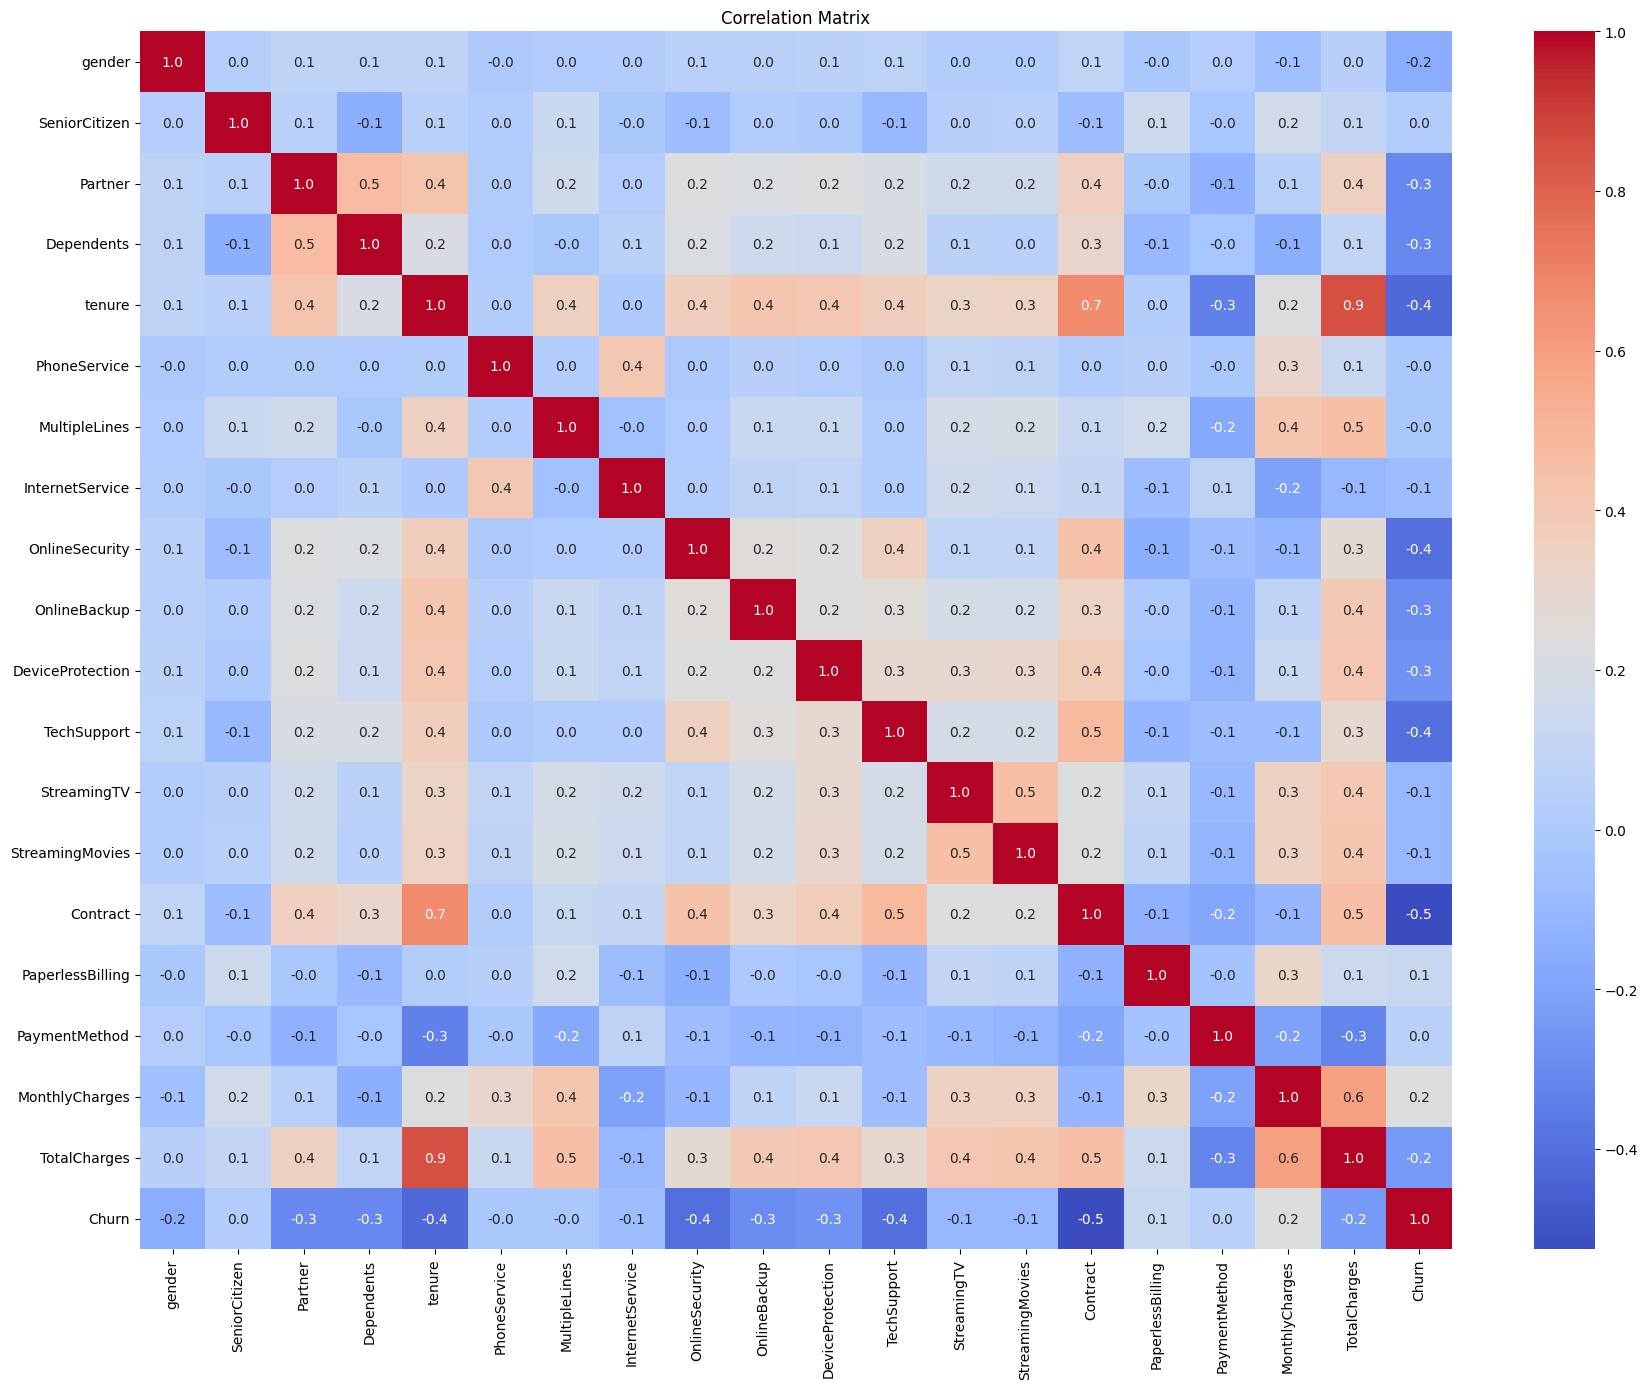

In [ ]:
# Correlation matrix
corr_matrix=df.corr()
# Heatmap of correlation matrix
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix,annot=True,fmt="0.01f",cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
df.drop('TotalCharges', axis=1, inplace=True)

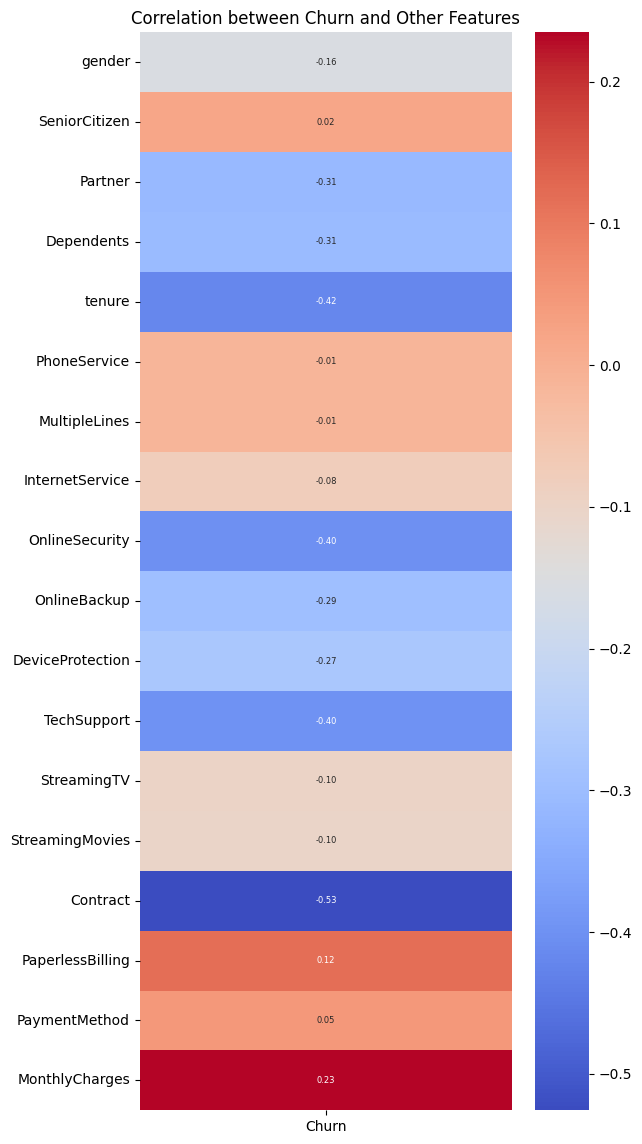

In [ ]:
# Calculate the correlation between 'HadHeartAttack' and all other columns
loan_status_corr=df.corr()['Churn']

# Remove the correlation of 'HadHeartAttack'with itself (which is always 1)
loan_status_corr=loan_status_corr.drop('Churn')
# Create a heatmap to visualize the correlations
plt.figure(figsize=(6, 14))
sns.heatmap(loan_status_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',
            cbar=True,annot_kws={'size':6}) # to_frame() converts Series to DataFrame for heatmap
plt.title('Correlation between Churn and Other Features')
plt.show()

In [ ]:
df.drop(['PhoneService', 'MultipleLines', 'SeniorCitizen'], axis=1, inplace=True)

<Axes: >

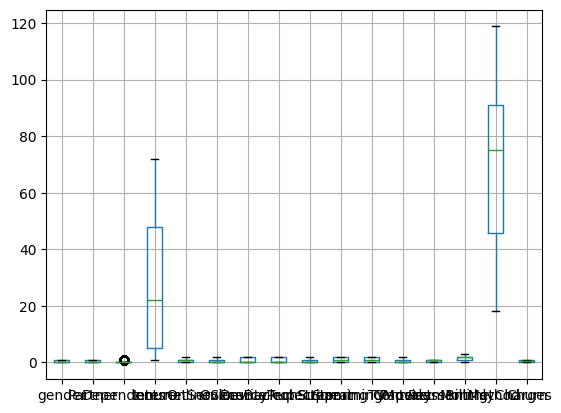

In [ ]:
df.boxplot()

In [ ]:
# Function to remove outliers using the IQR method except for one column
def remove_outliers_iqr(df,exclude_column):


  for col in df.columns:

   # Skip the specified column
    if col==exclude_column:
      continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    # Filter the DataFrame to remove rows with outliers in each column
    df=df[(df[col]>=lower_bound)&(df[col]<=upper_bound)]
  return df


# Specify the column to exclude
df_cleaned=remove_outliers_iqr(df,exclude_column="Churn")
df=df_cleaned

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
 #Select the features that you want to scale
features = [
        'gender',
        'Partner',
        'Dependents',
        'tenure',
        'InternetService',
        'OnlineSecurity',
        'OnlineBackup',
        'DeviceProtection',
        'TechSupport',
        'StreamingTV',
        'StreamingMovies',
        'Contract',
        'PaperlessBilling',
        'PaymentMethod',
        'MonthlyCharges']

y = df['Churn']
# Create a MinMaxScaler object
scaler = MinMaxScaler()
# Fit the scaler to your data and transform it
scaled_data = scaler.fit_transform(df[features])
# Create a DataFrame from scaled_data with the correct column names
scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=scaled_df
y=df["Churn"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
# Train a baseline logistic regression model
model=LogisticRegression()
model.fit(x_train,y_train)
# Predict and evaluate the model
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"baseline model accuracy:{accuracy:.2f}")

baseline model accuracy:0.76


In [ ]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression()
#track best fold data
best_accuracy=0
best_fold=-1

# Save best fold's data
best_x_train = None
best_y_train = None
best_x_test = None
best_y_test = None
best_y_pred = None

# Loop over each fold
for fold, (train_index, test_index) in enumerate(kf.split(x), 1):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train model
    model.fit(x_train, y_train)

    # Predict
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")

    # Update best fold
    if acc > best_accuracy:
      best_accuracy = acc
      best_fold = fold
      best_x_train = x_train
      best_y_train = y_train
      best_x_test = x_test
      best_y_test = y_test
      best_y_pred = y_pred
 # Output best fold details
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

Fold 1 Accuracy: 0.7588769611890999
Fold 2 Accuracy: 0.7687861271676301
Fold 3 Accuracy: 0.7696118909991743
Fold 4 Accuracy: 0.7663088356729976
Fold 5 Accuracy: 0.7530966143682907

 Best Fold: 3 with Accuracy: 0.7696118909991743


In [ ]:
model = LogisticRegression()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.7696118909991743

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.7522708505367465

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.8100743187448389

In [ ]:
from xgboost import XGBClassifier
model=XGBClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.8183319570602807

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
model=AdaBoostClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.7877786952931461

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Defining the ANN model
model = Sequential()
model.add(Dense(64, input_shape=(15,),activation='relu'))  # Hidden Layer 1
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))# Hidden Layer 2
model.add(Dense(1, activation='sigmoid'))             # Output Layer

# Compiling the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 3. Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Training the model
model.fit(best_x_train, best_y_train, epochs=30, batch_size=32)

Epoch 1/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8344 - loss: 0.3737
Epoch 2/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8344 - loss: 0.3689
Epoch 3/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8287 - loss: 0.3679
Epoch 4/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8284 - loss: 0.3673
Epoch 5/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8307 - loss: 0.3664
Epoch 6/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8361 - loss: 0.3660
Epoch 7/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8309 - loss: 0.3595
Epoch 8/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8313 - loss: 0.3585
Epoch 9/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8386 - loss: 0.3541
Epoch 10/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8353 - loss: 0.3574
Epoch 11/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8377 - loss: 0.3536
Epoch 12/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [ ]:
# Evaluating the model
loss, accuracy = model.evaluate( best_x_test, best_y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8043 - loss: 0.4478
Model Accuracy: 80.43%


##Conclusion

This project successfully developed a Customer Churn Prediction System using machine learning techniques to identify customers who are likely to discontinue a telecom service. The dataset was preprocessed through data cleaning, missing value handling, label encoding, feature selection, and correlation analysis. Exploratory Data Analysis (EDA) helped identify important factors influencing customer churn, such as Contract Type, Tenure, Online Security, and Tech Support. To reduce multicollinearity, the TotalCharges feature was removed, and features with very low correlation were excluded before model training.

Several machine learning algorithms were evaluated, and XGBoost achieved the highest prediction accuracy of 81.83%, outperforming the other models. The results demonstrate that machine learning can effectively predict customer churn and support businesses in identifying customers at risk of leaving. Such predictive models can help organizations implement targeted retention strategies, improve customer satisfaction, and reduce revenue loss through data-driven decision-making.